<a href="https://colab.research.google.com/github/anthony-yt/wildfire-cellular-automata/blob/main/notebooks/prueba_grid_sintetico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prueba del Grid
Probamos el grid con datos sintéticos, todavía sin viento, para ver que el fuego se expande en unos pasos.

In [3]:
import os

if os.path.exists('src'):
    pass
elif os.path.exists('../src'):
    %cd ..
else:
    if not os.path.exists('wildfire-cellular-automata'):
        !git clone https://github.com/anthony-yt/wildfire-cellular-automata.git
    %cd wildfire-cellular-automata

Cloning into 'wildfire-cellular-automata'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 28 (delta 4), reused 23 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 5.24 KiB | 1.75 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/wildfire-cellular-automata


In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from src.model.grid import Grid, SANA, NO_COMBUSTIBLE

In [5]:
grid = Grid(tamano=50, prob_ignicion_base=0.3, pasos_para_quemarse=2, semilla=42)

centro = grid.tamano // 2
grid.encender_celda(centro, centro)

grid.contar_estados()

{'Sana': 2499, 'Quemandose': 1, 'Quemada': 0, 'No_combustible': 0}

In [6]:
colores = ListedColormap(['green', 'red', 'black', 'gray'])

def graficar_grid(grid, titulo=''):
    plt.figure(figsize=(5, 5))
    plt.imshow(grid.estado, cmap=colores, vmin=SANA, vmax=NO_COMBUSTIBLE)
    plt.title(titulo)
    plt.axis('off')
    plt.show()

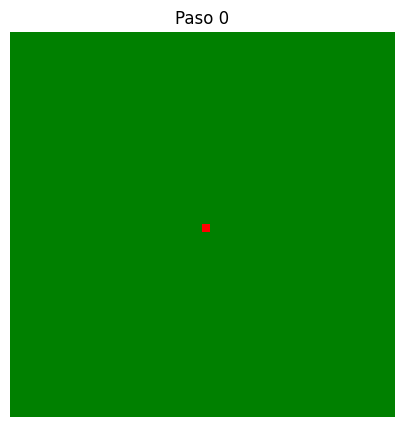

Paso 1: {'Sana': 2497, 'Quemandose': 3, 'Quemada': 0, 'No_combustible': 0}


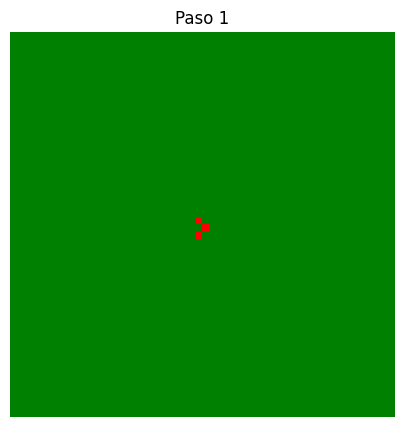

Paso 2: {'Sana': 2494, 'Quemandose': 5, 'Quemada': 1, 'No_combustible': 0}


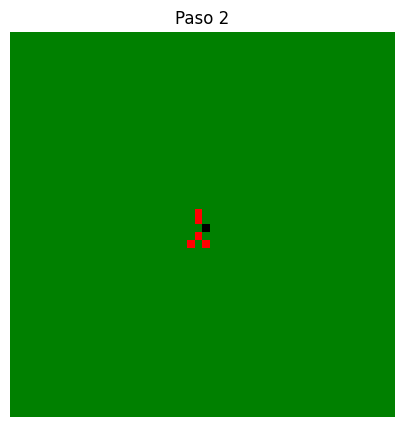

Paso 3: {'Sana': 2490, 'Quemandose': 7, 'Quemada': 3, 'No_combustible': 0}


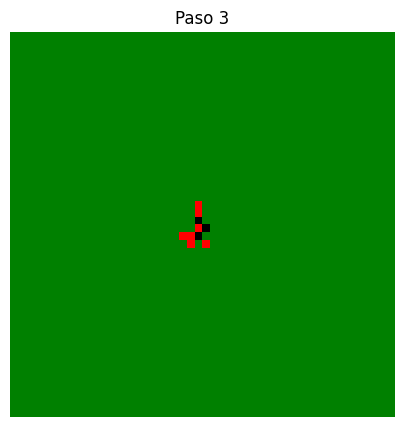

Paso 4: {'Sana': 2488, 'Quemandose': 6, 'Quemada': 6, 'No_combustible': 0}


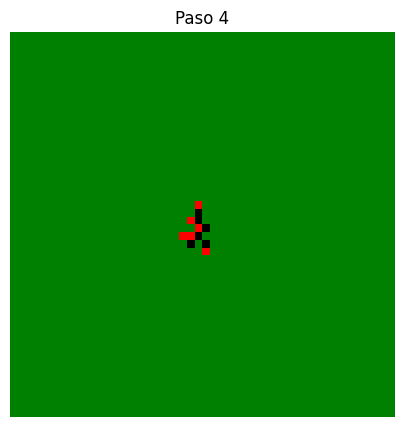

Paso 5: {'Sana': 2486, 'Quemandose': 4, 'Quemada': 10, 'No_combustible': 0}


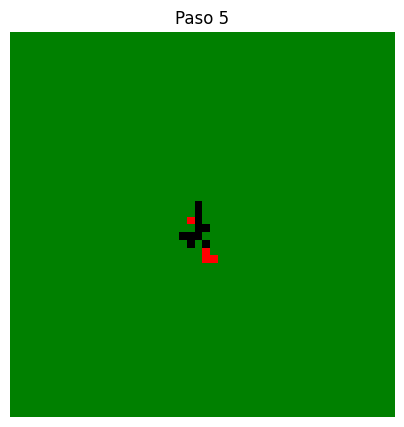

In [7]:
graficar_grid(grid, 'Paso 0')

for paso in range(1, 6):
    grid.paso_tiempo()
    print(f'Paso {paso}:', grid.contar_estados())
    graficar_grid(grid, f'Paso {paso}')